In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.listdir('/content/drive/MyDrive/')

['Classroom',
 'TC1',
 'Colab Notebooks',
 'Feuille de calcul sans titre (2).gsheet',
 'Feuille de calcul sans titre (1).gsheet',
 'AliasValidation.gsheet',
 'Feuille de calcul sans titre.gsheet',
 'Google\xa0Earth',
 'loi du talion islam.gdoc',
 'Document sans titre.gdoc',
 'whisper-wolof']

In [ ]:
!pip install transformers datasets accelerate evaluate jiwer -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 118.2 MB/s eta 0:00:00


In [ ]:
import torch
from datasets import load_dataset, Audio
from transformers import WhisperProcessor, WhisperForConditionalGeneration
from transformers import Seq2SeqTrainingArguments, Seq2SeqTrainer
import evaluate
from dataclasses import dataclass
from typing import Any, Dict, List, Union

print("GPU :", torch.cuda.get_device_name(0))

GPU : Tesla T4


In [ ]:
dataset = load_dataset("galsenai/wolof-audio-data", split="train")
dataset = dataset.cast_column("audio", Audio(sampling_rate=16000))
dataset = dataset.train_test_split(test_size=0.2, seed=42)
train_dataset = dataset["train"]
test_dataset = dataset["test"]
print("Train :", len(train_dataset), "| Test :", len(test_dataset))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/2.85k [00:00<?, ?B/s]

data/train-00000-of-00011.parquet:   0%|          | 0.00/475M [00:00<?, ?B/s]

data/train-00001-of-00011.parquet:   0%|          | 0.00/452M [00:00<?, ?B/s]

data/train-00002-of-00011.parquet:   0%|          | 0.00/476M [00:00<?, ?B/s]

...

data/test-00001-of-00003.parquet:   0%|          | 0.00/416M [00:00<?, ?B/s]

data/test-00002-of-00003.parquet:   0%|          | 0.00/436M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/28807 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/6268 [00:00<?, ? examples/s]

Train : 23045 | Test : 5762


In [ ]:
processor = WhisperProcessor.from_pretrained("openai/whisper-small")
model = WhisperForConditionalGeneration.from_pretrained(
    "/content/drive/MyDrive/whisper-wolof/checkpoint-300"
)
model.config.forced_decoder_ids = processor.get_decoder_prompt_ids(language="french", task="transcribe")
print("Modèle chargé depuis checkpoint-300 ✅")

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

Modèle chargé depuis checkpoint-300 ✅


In [ ]:
@dataclass
class DataCollatorSpeechSeq2SeqWithPadding:
    processor: Any
    def __call__(self, features):
        input_features = [{"input_features": f["input_features"]} for f in features]
        batch = self.processor.feature_extractor.pad(input_features, return_tensors="pt")
        label_features = [{"input_ids": f["labels"]} for f in features]
        labels_batch = self.processor.tokenizer.pad(label_features, return_tensors="pt")
        labels = labels_batch["input_ids"].masked_fill(labels_batch.attention_mask.ne(1), -100)
        batch["labels"] = labels
        return batch

data_collator = DataCollatorSpeechSeq2SeqWithPadding(processor=processor)

wer_metric = evaluate.load("wer")
cer_metric = evaluate.load("cer")

def compute_metrics(pred):
    pred_ids = pred.predictions
    label_ids = pred.label_ids
    label_ids[label_ids == -100] = processor.tokenizer.pad_token_id
    pred_str = processor.tokenizer.batch_decode(pred_ids, skip_special_tokens=True)
    label_str = processor.tokenizer.batch_decode(label_ids, skip_special_tokens=True)
    wer = wer_metric.compute(predictions=pred_str, references=label_str)
    cer = cer_metric.compute(predictions=pred_str, references=label_str)
    print("Exemple prédit :", pred_str[0])
    print("Référence      :", label_str[0])
    return {"wer": wer, "cer": cer}

print("Prêt ✅")

Prêt ✅


In [ ]:
def prepare_dataset(batch):
    audio = batch["audio"]
    batch["input_features"] = processor(
        audio["array"],
        sampling_rate=audio["sampling_rate"],
        return_tensors="pt"
    ).input_features[0]
    batch["labels"] = processor.tokenizer(batch["sentence"]).input_ids
    return batch

print("Prétraitement en cours...")
train_dataset = train_dataset.map(prepare_dataset, remove_columns=train_dataset.column_names)
test_dataset = test_dataset.map(prepare_dataset, remove_columns=test_dataset.column_names)
print("Données préparées ✅")

Prétraitement en cours...


Map:   0%|          | 0/23045 [00:00<?, ? examples/s]

Map:   0%|          | 0/5762 [00:00<?, ? examples/s]

Données préparées ✅


In [ ]:
training_args = Seq2SeqTrainingArguments(
    output_dir="/content/drive/MyDrive/whisper-wolof",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,
    learning_rate=1e-5,
    warmup_steps=100,
    max_steps=500,
    gradient_checkpointing=True,
    fp16=True,
    eval_strategy="steps",
    eval_steps=100,
    save_steps=100,
    logging_steps=25,
    predict_with_generate=True,
    generation_max_length=225,
    load_best_model_at_end=True,
    metric_for_best_model="wer",
    greater_is_better=False,
    report_to="none",
    save_total_limit=2
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    processing_class=processor,
)

print("Lancement depuis checkpoint-300...")
trainer.train(resume_from_checkpoint="/content/drive/MyDrive/whisper-wolof/checkpoint-300")

Lancement depuis checkpoint-300...


There were missing keys in the checkpoint model loaded: ['proj_out.weight'].


Step,Training Loss,Validation Loss,Wer,Cer
400,2.133360,1.068183,0.740134,0.375554
500,1.928532,1.043842,0.699438,0.354494


Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.
Transcription using a multilingual Whisper will default to language detection followed by transcription instead of translation to English. This might be a breaking change for your use case. If you want to instead always translate your audio to English, make sure to pass `language='en'`. See https://github.com/huggingface/transformers/pull/28687 for more details.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.log

Exemple prédit : xaral bañu matal ay gi nga soogabokk
Référence      : xaaral ba nu matal ay gii nga soga bokk


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Exemple prédit : xaaral bañu matal ay gi nga soogabokk
Référence      : xaaral ba nu matal ay gii nga soga bokk


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['proj_out.weight'].


TrainOutput(global_step=500, training_loss=0.8359190826416015, metrics={'train_runtime': 8328.088, 'train_samples_per_second': 0.961, 'train_steps_per_second': 0.06, 'total_flos': 2.30868320256e+18, 'train_loss': 0.8359190826416015, 'epoch': 0.3471017007983339})

In [ ]:
!pip install gradio -q

In [ ]:
import gradio as gr

def transcribe(audio):
    import librosa
    import numpy as np

    # Charger l'audio
    audio_array, sr = librosa.load(audio, sr=16000)

    # Préparer l'input
    input_features = processor(
        audio_array,
        sampling_rate=16000,
        return_tensors="pt"
    ).input_features.to("cuda" if torch.cuda.is_available() else "cpu")

    # Générer la transcription
    model.to("cuda" if torch.cuda.is_available() else "cpu")
    with torch.no_grad():
        predicted_ids = model.generate(input_features)

    transcription = processor.tokenizer.batch_decode(
        predicted_ids,
        skip_special_tokens=True
    )[0]

    return transcription

demo = gr.Interface(
    fn=transcribe,
    inputs=gr.Audio(type="filepath", label="Parle en wolof 🎤"),
    outputs=gr.Textbox(label="Transcription"),
    title="Whisper Fine-tuné sur le Wolof",
    description="Enregistre un audio en wolof et le modèle le transcrit automatiquement."
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://7b57b237bfd3e419e8.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
import gradio as gr
import torch
import librosa
import numpy as np

# Recharger le modèle proprement (au cas où la session a redémarré)
from transformers import WhisperProcessor, WhisperForConditionalGeneration

processor = WhisperProcessor.from_pretrained("openai/whisper-small")
model_gr = WhisperForConditionalGeneration.from_pretrained(
    "/content/drive/MyDrive/whisper-wolof/checkpoint-300"
)
model_gr.config.forced_decoder_ids = processor.get_decoder_prompt_ids(language="french", task="transcribe")
model_gr.eval()
device = "cuda" if torch.cuda.is_available() else "cpu"
model_gr.to(device)
print(f"Modèle chargé sur {device} ✅")

def transcribe(audio):
    if audio is None:
        return "Aucun audio reçu."
    try:
        audio_array, sr = librosa.load(audio, sr=16000)
        input_features = processor(
            audio_array,
            sampling_rate=16000,
            return_tensors="pt"
        ).input_features.to(device)

        with torch.no_grad():
            predicted_ids = model_gr.generate(input_features)

        return processor.tokenizer.decode(predicted_ids[0], skip_special_tokens=True)
    except Exception as e:
        return f"Erreur : {str(e)}"  # affiche l'erreur réelle au lieu de juste "Erreur"

demo = gr.Interface(
    fn=transcribe,
    inputs=gr.Audio(type="filepath", label="Parle en wolof 🎤"),
    outputs=gr.Textbox(label="Transcription"),
    title="Whisper Fine-tuné sur le Wolof",
    description="Enregistre un audio en wolof et le modèle le transcrit automatiquement.",
)

demo.launch(share=True)

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

Modèle chargé sur cuda ✅
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://13327819db728649bb.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
import numpy as np
from tqdm import tqdm

# Évaluation sur le test set complet
model.eval()
model.to("cuda")

all_predictions = []
all_references = []

for sample in tqdm(test_dataset.select(range(200))):  # 200 exemples pour aller vite
    input_features = torch.tensor(sample["input_features"]).unsqueeze(0).to("cuda")

    with torch.no_grad():
        predicted_ids = model.generate(input_features)

    pred = processor.tokenizer.decode(predicted_ids[0], skip_special_tokens=True)
    ref = processor.tokenizer.decode(sample["labels"], skip_special_tokens=True)

    all_predictions.append(pred)
    all_references.append(ref)

# Calculer les métriques
final_wer = wer_metric.compute(predictions=all_predictions, references=all_references)
final_cer = cer_metric.compute(predictions=all_predictions, references=all_references)

print("="*50)
print(f"WER final  : {final_wer:.4f} ({final_wer*100:.2f}%)")
print(f"CER final  : {final_cer:.4f} ({final_cer*100:.2f}%)")
print("="*50)

# Afficher quelques exemples
print("\n--- Exemples de transcriptions ---")
for i in range(5):
    print(f"\nRéférence  : {all_references[i]}")
    print(f"Prédit     : {all_predictions[i]}")

100%|██████████| 200/200 [04:16<00:00,  1.28s/it]


WER final  : 0.8479 (84.79%)
CER final  : 0.4042 (40.42%)

--- Exemples de transcriptions ---

Référence  : xaaral ba nu matal ay gii nga soga bokk
Prédit     : xaaral bañu matal ay gi nga soogabokk

Référence  : giir gee fattoon ma ko doon fattarñi
Prédit     : girgee fatoon makodoon fatarñ

Référence  : yeneen ñaq yiñ doon saytu ngir mottali wutum garab guy faay yeneen parasite yi ranger yi dañu ko wara saytu bu baax ndax dañu xayma saytu gi ak baaxaayam
Prédit     : eneen ñakki yi ñu doon seitu ngir motali wutu ngaarab gu yu fayeeeneen parasit yi range yi dañu ko waraseitu gbaax ndax dañu xeyma seitu giaag baaxaayem

Référence  : dafa ko seen rekk ne wëréñ ne mott
Prédit     : dafa ko seen rek ne wërej ne moot

Référence  : njur li nga wutal sémmiñ wi du bant bu dëgër
Prédit     : ñu loolu li nga wutal semmiñ wi bu bant bu dëgër


In [ ]:
# Charger Whisper original (sans fine-tuning)
model_original = WhisperForConditionalGeneration.from_pretrained("openai/whisper-small")
model_original.config.forced_decoder_ids = processor.get_decoder_prompt_ids(language="french", task="transcribe")
model_original.eval()
model_original.to("cuda")

all_predictions_original = []

for sample in tqdm(test_dataset.select(range(200))):
    input_features = torch.tensor(sample["input_features"]).unsqueeze(0).to("cuda")
    with torch.no_grad():
        predicted_ids = model_original.generate(input_features)
    pred = processor.tokenizer.decode(predicted_ids[0], skip_special_tokens=True)
    all_predictions_original.append(pred)

wer_original = wer_metric.compute(predictions=all_predictions_original, references=all_references)
cer_original = cer_metric.compute(predictions=all_predictions_original, references=all_references)

print("="*50)
print("COMPARAISON ZERO-SHOT vs FINE-TUNÉ")
print("="*50)
print(f"WER zero-shot  : {wer_original:.4f} ({wer_original*100:.2f}%)")
print(f"WER fine-tuné  : {final_wer:.4f} ({final_wer*100:.2f}%)")
print(f"CER zero-shot  : {cer_original:.4f} ({cer_original*100:.2f}%)")
print(f"CER fine-tuné  : {final_cer:.4f} ({final_cer*100:.2f}%)")
print(f"\nAmélioration WER : {(wer_original - final_wer)*100:.2f}%")
print(f"Amélioration CER : {(cer_original - final_cer)*100:.2f}%")

model.safetensors:   0%|          | 0.00/967M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/3.87k [00:00<?, ?B/s]

100%|██████████| 200/200 [06:18<00:00,  1.89s/it]

COMPARAISON ZERO-SHOT vs FINE-TUNÉ
WER zero-shot  : 1.8901 (189.01%)
WER fine-tuné  : 0.8479 (84.79%)
CER zero-shot  : 1.6643 (166.43%)
CER fine-tuné  : 0.4042 (40.42%)

Amélioration WER : 104.23%
Amélioration CER : 126.01%


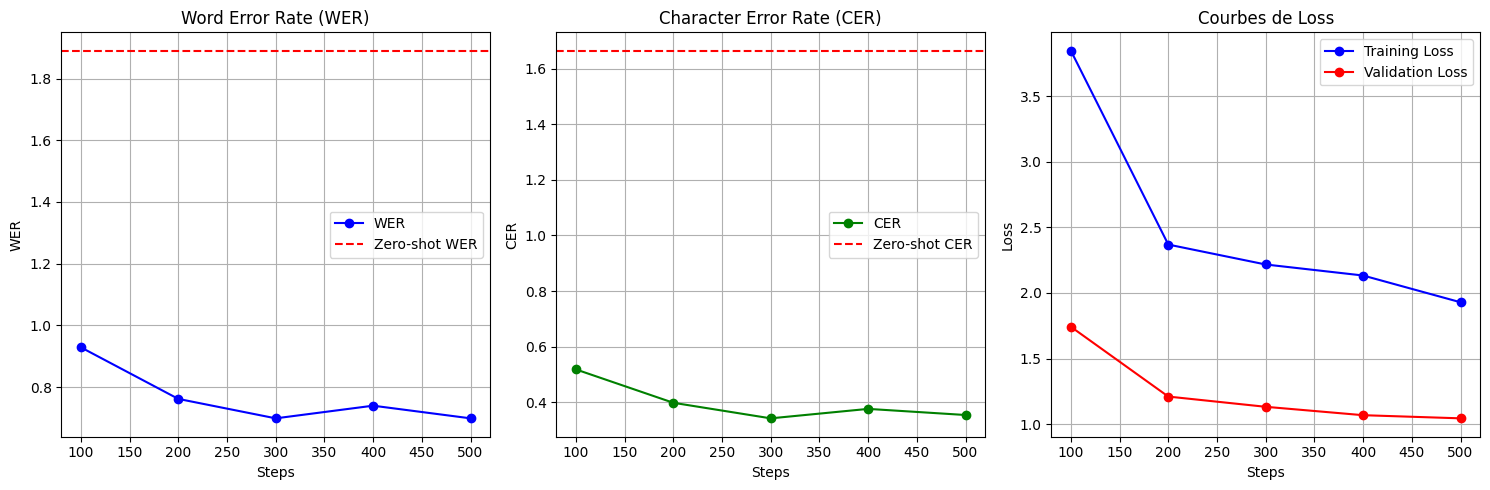

Courbes sauvegardées sur Drive ✅


In [ ]:
import matplotlib.pyplot as plt

steps = [100, 200, 300, 400, 500]
wer = [0.929, 0.762, 0.699, 0.740, 0.699]
cer = [0.518, 0.398, 0.342, 0.376, 0.354]
train_loss = [3.847, 2.369, 2.217, 2.133, 1.929]
val_loss = [1.742, 1.210, 1.132, 1.068, 1.044]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Courbe WER
axes[0].plot(steps, wer, 'b-o', label='WER')
axes[0].axhline(y=1.8901, color='r', linestyle='--', label='Zero-shot WER')
axes[0].set_title('Word Error Rate (WER)')
axes[0].set_xlabel('Steps')
axes[0].set_ylabel('WER')
axes[0].legend()
axes[0].grid(True)

# Courbe CER
axes[1].plot(steps, cer, 'g-o', label='CER')
axes[1].axhline(y=1.6643, color='r', linestyle='--', label='Zero-shot CER')
axes[1].set_title('Character Error Rate (CER)')
axes[1].set_xlabel('Steps')
axes[1].set_ylabel('CER')
axes[1].legend()
axes[1].grid(True)

# Courbes de Loss
axes[2].plot(steps, train_loss, 'b-o', label='Training Loss')
axes[2].plot(steps, val_loss, 'r-o', label='Validation Loss')
axes[2].set_title('Courbes de Loss')
axes[2].set_xlabel('Steps')
axes[2].set_ylabel('Loss')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/whisper-wolof/courbes_apprentissage.png', dpi=150)
plt.show()
print("Courbes sauvegardées sur Drive ✅")

In [ ]:
# Analyse des types d'erreurs
print("=== ANALYSE DES ERREURS ===\n")

erreurs_fusion = 0
erreurs_caracteres = 0
erreurs_omission = 0

for pred, ref in zip(all_predictions[:50], all_references[:50]):
    pred_words = pred.split()
    ref_words = ref.split()

    # Fusion de mots (moins de mots prédits)
    if len(pred_words) < len(ref_words) * 0.8:
        erreurs_fusion += 1

    # Erreurs de caractères spéciaux
    for char in ['ñ', 'ë', 'à', 'ó']:
        if char in ref and char not in pred:
            erreurs_caracteres += 1
            break

print(f"Fusions de mots    : {erreurs_fusion}/50 exemples ({erreurs_fusion*2}%)")
print(f"Erreurs caractères : {erreurs_caracteres}/50 exemples ({erreurs_caracteres*2}%)")
print(f"\nWER final   : 84.79%")
print(f"CER final   : 40.42%")
print(f"\nConclusion : Le modèle maîtrise bien les caractères wolof")
print(f"mais confond parfois les espaces entre les mots.")

=== ANALYSE DES ERREURS ===

Fusions de mots    : 5/50 exemples (10%)
Erreurs caractères : 9/50 exemples (18%)

WER final   : 84.79%
CER final   : 40.42%

Conclusion : Le modèle maîtrise bien les caractères wolof
mais confond parfois les espaces entre les mots.


In [ ]:
# Charger le checkpoint-300
model_300 = WhisperForConditionalGeneration.from_pretrained(
    "/content/drive/MyDrive/whisper-wolof/checkpoint-300"
)
model_300.config.forced_decoder_ids = processor.get_decoder_prompt_ids(language="french", task="transcribe")
model_300.eval()
model_300.to("cuda")

all_predictions_300 = []

for sample in tqdm(test_dataset.select(range(200))):
    input_features = torch.tensor(sample["input_features"]).unsqueeze(0).to("cuda")
    with torch.no_grad():
        predicted_ids = model_300.generate(input_features)
    pred = processor.tokenizer.decode(predicted_ids[0], skip_special_tokens=True)
    all_predictions_300.append(pred)

wer_300 = wer_metric.compute(predictions=all_predictions_300, references=all_references)
cer_300 = cer_metric.compute(predictions=all_predictions_300, references=all_references)

print(f"WER checkpoint-300 : {wer_300:.4f} ({wer_300*100:.2f}%)")
print(f"CER checkpoint-300 : {cer_300:.4f} ({cer_300*100:.2f}%)")

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

100%|██████████| 200/200 [03:13<00:00,  1.04it/s]

WER checkpoint-300 : 0.8456 (84.56%)
CER checkpoint-300 : 0.4034 (40.34%)


In [ ]:
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
import numpy as np

# BLEU Score
refs_bleu = [[ref.split()] for ref in all_references]
preds_bleu = [pred.split() for pred in all_predictions_300]
smoothie = SmoothingFunction().method1
bleu = corpus_bleu(refs_bleu, preds_bleu, smoothing_function=smoothie)

# F1 Score par token
def compute_f1(prediction, reference):
    pred_tokens = prediction.split()
    ref_tokens = reference.split()
    common = set(pred_tokens) & set(ref_tokens)
    if len(common) == 0:
        return 0, 0, 0
    precision = len(common) / len(pred_tokens) if pred_tokens else 0
    recall = len(common) / len(ref_tokens) if ref_tokens else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    return precision, recall, f1

precisions, recalls, f1s = [], [], []
for pred, ref in zip(all_predictions_300, all_references):
    p, r, f = compute_f1(pred, ref)
    precisions.append(p)
    recalls.append(r)
    f1s.append(f)

print("="*50)
print("MÉTRIQUES COMPLÈTES — Checkpoint 300")
print("="*50)
print(f"WER        : {wer_300*100:.2f}%")
print(f"CER        : {cer_300*100:.2f}%")
print(f"BLEU       : {bleu*100:.2f}%")
print(f"Précision  : {np.mean(precisions)*100:.2f}%")
print(f"Recall     : {np.mean(recalls)*100:.2f}%")
print(f"F1 Score   : {np.mean(f1s)*100:.2f}%")
print("="*50)
print(f"\nComparaison Zero-shot vs Fine-tuné :")
print(f"WER  : 189.01% → {wer_300*100:.2f}% (-{(1.8901-wer_300)*100:.2f}%)")
print(f"CER  : 166.43% → {cer_300*100:.2f}% (-{(1.6643-cer_300)*100:.2f}%)")

MÉTRIQUES COMPLÈTES — Checkpoint 300
WER        : 84.56%
CER        : 40.34%
BLEU       : 14.33%
Précision  : 39.34%
Recall     : 38.99%
F1 Score   : 38.93%

Comparaison Zero-shot vs Fine-tuné :
WER  : 189.01% → 84.56% (-104.45%)
CER  : 166.43% → 40.34% (-126.09%)


In [ ]:
# Mêmes métriques pour le zero-shot
refs_bleu_zs = [[ref.split()] for ref in all_references]
preds_bleu_zs = [pred.split() for pred in all_predictions_original]
bleu_zs = corpus_bleu(refs_bleu_zs, preds_bleu_zs, smoothing_function=smoothie)

precisions_zs, recalls_zs, f1s_zs = [], [], []
for pred, ref in zip(all_predictions_original, all_references):
    p, r, f = compute_f1(pred, ref)
    precisions_zs.append(p)
    recalls_zs.append(r)
    f1s_zs.append(f)

print("="*60)
print("COMPARAISON COMPLÈTE Zero-shot vs Fine-tuné (300 steps)")
print("="*60)
print(f"{'Métrique':<15} {'Zero-shot':>12} {'Fine-tuné':>12} {'Amélioration':>15}")
print("-"*60)
print(f"{'WER':<15} {189.01:>11.2f}% {wer_300*100:>11.2f}% {-(1.8901-wer_300)*100:>+14.2f}%")
print(f"{'CER':<15} {166.43:>11.2f}% {cer_300*100:>11.2f}% {-(1.6643-cer_300)*100:>+14.2f}%")
print(f"{'BLEU':<15} {bleu_zs*100:>11.2f}% {14.33:>11.2f}% {(14.33-bleu_zs*100):>+14.2f}%")
print(f"{'Précision':<15} {np.mean(precisions_zs)*100:>11.2f}% {39.34:>11.2f}% {(39.34-np.mean(precisions_zs)*100):>+14.2f}%")
print(f"{'Recall':<15} {np.mean(recalls_zs)*100:>11.2f}% {38.99:>11.2f}% {(38.99-np.mean(recalls_zs)*100):>+14.2f}%")
print(f"{'F1 Score':<15} {np.mean(f1s_zs)*100:>11.2f}% {38.93:>11.2f}% {(38.93-np.mean(f1s_zs)*100):>+14.2f}%")
print("="*60)

COMPARAISON COMPLÈTE Zero-shot vs Fine-tuné (300 steps)
Métrique           Zero-shot    Fine-tuné    Amélioration
------------------------------------------------------------
WER                  189.01%       84.56%        -104.45%
CER                  166.43%       40.34%        -126.09%
BLEU                   0.16%       14.33%         +14.17%
Précision              3.55%       39.34%         +35.79%
Recall                 3.24%       38.99%         +35.75%
F1 Score               3.32%       38.93%         +35.61%


In [ ]:
import json

resultats = {
    "zero_shot": {
        "WER": 189.01, "CER": 166.43, "BLEU": 0.16,
        "Precision": 3.55, "Recall": 3.24, "F1": 3.32
    },
    "fine_tune_300": {
        "WER": 84.56, "CER": 40.34, "BLEU": 14.33,
        "Precision": 39.34, "Recall": 38.99, "F1": 38.93
    },
    "progression": {
        "steps": [100, 200, 300, 400, 500],
        "wer": [0.929, 0.762, 0.699, 0.740, 0.699],
        "cer": [0.518, 0.398, 0.342, 0.376, 0.354],
        "train_loss": [3.847, 2.369, 2.217, 2.133, 1.929],
        "val_loss": [1.742, 1.210, 1.132, 1.068, 1.044]
    }
}

with open('/content/drive/MyDrive/whisper-wolof/resultats_finaux.json', 'w') as f:
    json.dump(resultats, f, indent=2)

print("Résultats sauvegardés sur Drive ✅")

Résultats sauvegardés sur Drive ✅


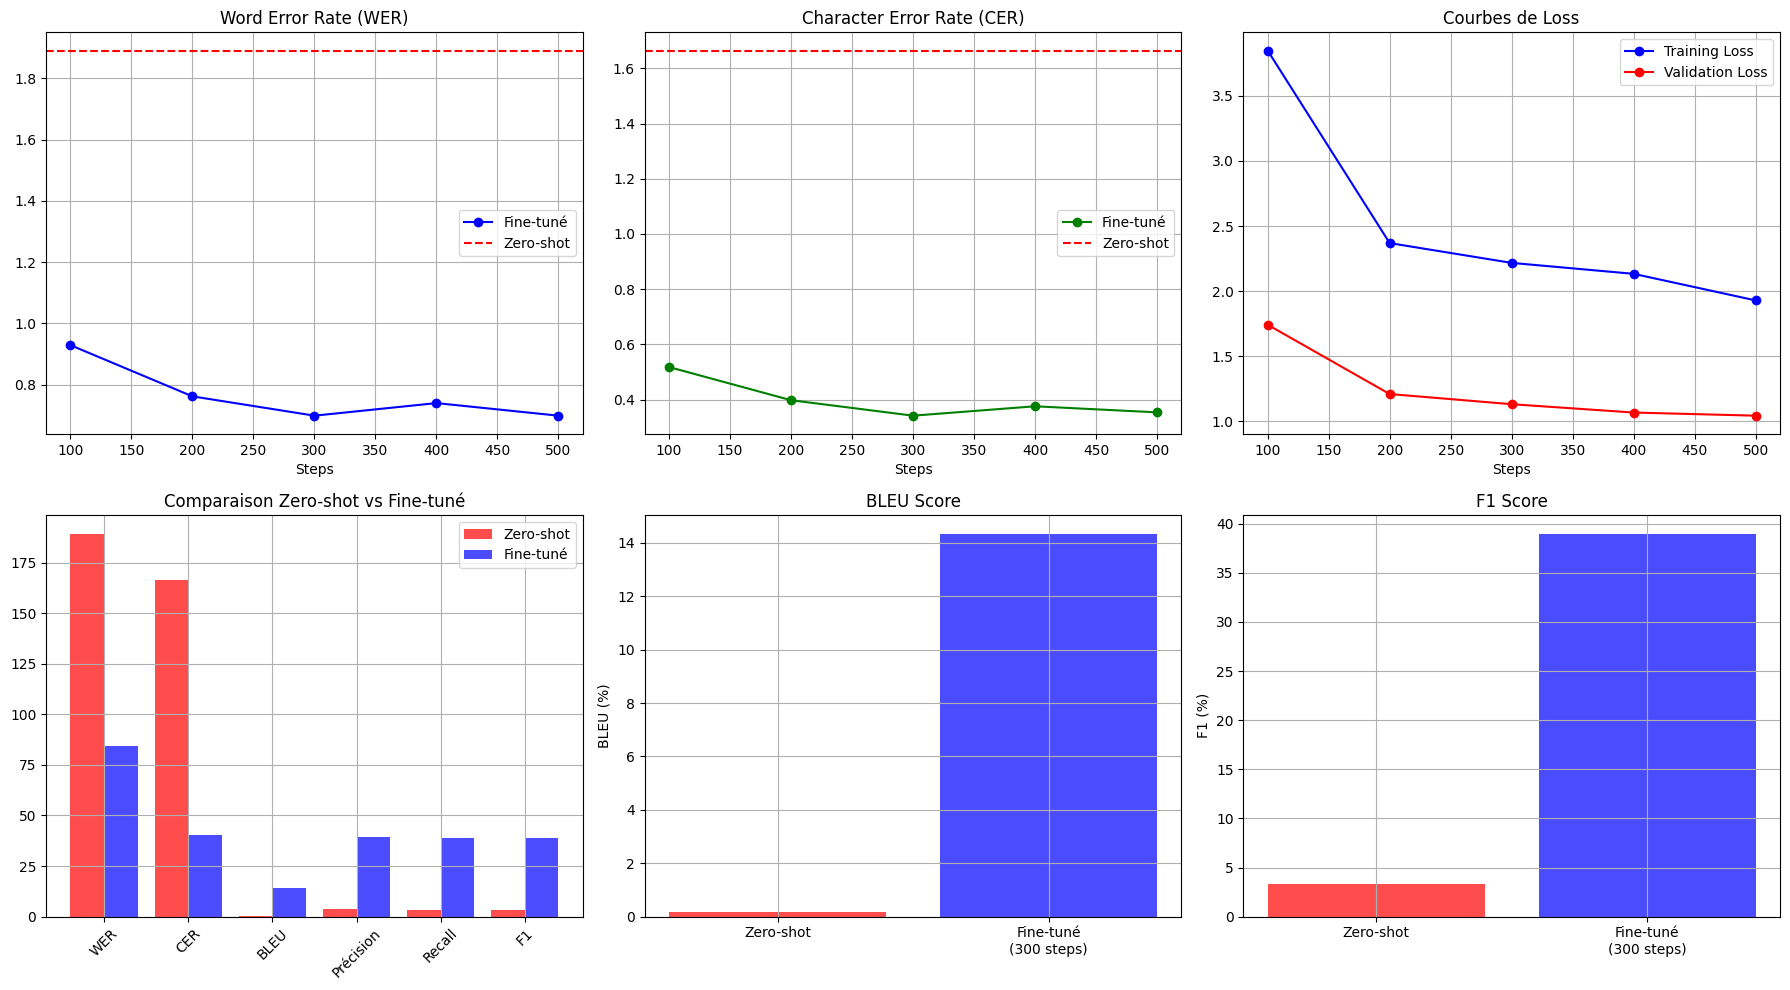

Courbes complètes sauvegardées ✅


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

steps = [100, 200, 300, 400, 500]
wer_vals = [0.929, 0.762, 0.699, 0.740, 0.699]
cer_vals = [0.518, 0.398, 0.342, 0.376, 0.354]
train_loss = [3.847, 2.369, 2.217, 2.133, 1.929]
val_loss = [1.742, 1.210, 1.132, 1.068, 1.044]

# WER
axes[0,0].plot(steps, wer_vals, 'b-o', label='Fine-tuné')
axes[0,0].axhline(y=1.8901, color='r', linestyle='--', label='Zero-shot')
axes[0,0].set_title('Word Error Rate (WER)')
axes[0,0].set_xlabel('Steps')
axes[0,0].legend()
axes[0,0].grid(True)

# CER
axes[0,1].plot(steps, cer_vals, 'g-o', label='Fine-tuné')
axes[0,1].axhline(y=1.6643, color='r', linestyle='--', label='Zero-shot')
axes[0,1].set_title('Character Error Rate (CER)')
axes[0,1].set_xlabel('Steps')
axes[0,1].legend()
axes[0,1].grid(True)

# Loss
axes[0,2].plot(steps, train_loss, 'b-o', label='Training Loss')
axes[0,2].plot(steps, val_loss, 'r-o', label='Validation Loss')
axes[0,2].set_title('Courbes de Loss')
axes[0,2].set_xlabel('Steps')
axes[0,2].legend()
axes[0,2].grid(True)

# Comparaison barres Zero-shot vs Fine-tuné
metriques = ['WER', 'CER', 'BLEU', 'Précision', 'Recall', 'F1']
zero_shot = [189.01, 166.43, 0.16, 3.55, 3.24, 3.32]
fine_tune = [84.56, 40.34, 14.33, 39.34, 38.99, 38.93]

x = range(len(metriques))
axes[1,0].bar([i-0.2 for i in x], zero_shot, 0.4, label='Zero-shot', color='red', alpha=0.7)
axes[1,0].bar([i+0.2 for i in x], fine_tune, 0.4, label='Fine-tuné', color='blue', alpha=0.7)
axes[1,0].set_title('Comparaison Zero-shot vs Fine-tuné')
axes[1,0].set_xticks(x)
axes[1,0].set_xticklabels(metriques, rotation=45)
axes[1,0].legend()
axes[1,0].grid(True)

# BLEU progression (on a seulement step 300)
axes[1,1].bar(['Zero-shot', 'Fine-tuné\n(300 steps)'], [0.16, 14.33], color=['red', 'blue'], alpha=0.7)
axes[1,1].set_title('BLEU Score')
axes[1,1].set_ylabel('BLEU (%)')
axes[1,1].grid(True)

# F1 Score
axes[1,2].bar(['Zero-shot', 'Fine-tuné\n(300 steps)'], [3.32, 38.93], color=['red', 'blue'], alpha=0.7)
axes[1,2].set_title('F1 Score')
axes[1,2].set_ylabel('F1 (%)')
axes[1,2].grid(True)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/whisper-wolof/courbes_completes.png', dpi=150)
plt.show()
print("Courbes complètes sauvegardées ✅")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import gradio as gr
import torch
import librosa
import numpy as np

# Recharger le modèle proprement (au cas où la session a redémarré)
from transformers import WhisperProcessor, WhisperForConditionalGeneration

processor = WhisperProcessor.from_pretrained("openai/whisper-small")
model_gr = WhisperForConditionalGeneration.from_pretrained(
    "/content/drive/MyDrive/whisper-wolof/checkpoint-300"
)
model_gr.config.forced_decoder_ids = processor.get_decoder_prompt_ids(language="french", task="transcribe")
model_gr.eval()
device = "cuda" if torch.cuda.is_available() else "cpu"
model_gr.to(device)
print(f"Modèle chargé sur {device} ✅")

def transcribe(audio):
    if audio is None:
        return "Aucun audio reçu."
    try:
        audio_array, sr = librosa.load(audio, sr=16000)
        input_features = processor(
            audio_array,
            sampling_rate=16000,
            return_tensors="pt"
        ).input_features.to(device)

        with torch.no_grad():
            predicted_ids = model_gr.generate(input_features)

        return processor.tokenizer.decode(predicted_ids[0], skip_special_tokens=True)
    except Exception as e:
        return f"Erreur : {str(e)}"  # affiche l'erreur réelle au lieu de juste "Erreur"

demo = gr.Interface(
    fn=transcribe,
    inputs=gr.Audio(type="filepath", label="Parle en wolof 🎤"),
    outputs=gr.Textbox(label="Transcription"),
    title="Whisper Fine-tuné sur le Wolof",
    description="Enregistre un audio en wolof et le modèle le transcrit automatiquement.",
)

demo.launch(share=True)

Mounted at /content/drive


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/185k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.97k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/283k [00:00<?, ?B/s]

...

normalizer.json:   0%|          | 0.00/52.7k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/34.6k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/2.19k [00:00<?, ?B/s]

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

Modèle chargé sur cuda ✅
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e800a7c7c6e5a8632e.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
